# Deep Schema Grounding
Let's implement Deep Schema Grounding on the Visual Abstractions Dataset. We will be using GPT-4o as our base VLM.

In [1]:
# Let's first install the OpenAI library.
!pip install openai

In [ ]:
# Import necessary libraries and input your OpenAI API key.
from openai import OpenAI
from collections import defaultdict
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image
import requests
import textwrap
import base64
import pickle
import json
import time
import re
import os

api_key = ''

In [3]:
# Then download the Visual Abstractions dataset.
!wget https://downloads.cs.stanford.edu/viscam/VisualAbstractionsDataset/VAD.zip
!unzip VAD.zip

--2026-03-29 18:05:12--  https://downloads.cs.stanford.edu/viscam/VisualAbstractionsDataset/VAD.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 205624776 (196M) [application/zip]
Saving to: ‘VAD.zip’

VAD.zip             100%[===================>] 196.10M  4.94MB/s    in 36s     

2026-03-29 18:05:48 (5.47 MB/s) - ‘VAD.zip’ saved [205624776/205624776]

Archive:  VAD.zip
  inflating: VAD/README.md           
  inflating: VAD/domestic_concepts/setting_up_table_for_two/vqa.json  
  inflating: VAD/domestic_concepts/setting_up_table_for_two/15.jpg  
  inflating: VAD/domestic_concepts/setting_up_table_for_two/14.jpg  
  inflating: VAD/domestic_concepts/setting_up_table_for_two/13.jpg  
  inflating: VAD/domestic_concepts/setting_up_table_for_two/6.jpg  
  inflating: VAD/domestic_concepts/setting_up_table_

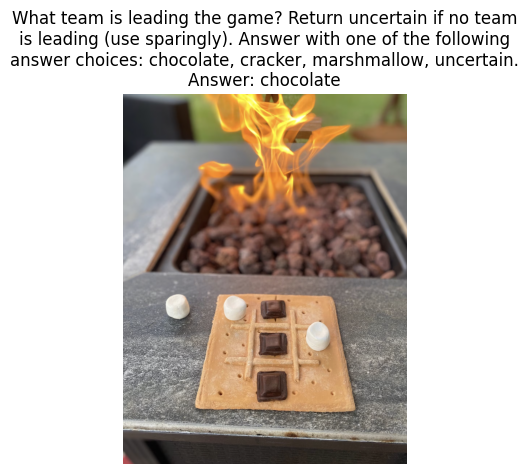

In [4]:
# Here, we'll visualize an example from the dataset.
img_path = '/content/VAD/strategic_concepts/tic_tac_toe/9.jpg'
vqa_path = '/content/VAD/strategic_concepts/tic_tac_toe/vqa.json'

img = mpimg.imread(img_path)

with open(vqa_path) as f:
    vqa = json.load(f)['questions']
vqa_example = [(this_vqa['question_multiple_choice'], this_vqa['answer_multiple_choice']) for this_vqa in vqa if this_vqa['image_filename'] == img_path.split('/')[-1]][2]
vqa_example = vqa_example[0] + '\nAnswer: ' + vqa_example[1]
vqa_example = '\n'.join(textwrap.wrap(vqa_example, width=60))

plt.imshow(img)
plt.title(vqa_example)
plt.axis('off')
plt.show()


In [5]:
# Let's define helper functions to retrieve the schema component queries and responses.
def get_symbolic_program(program_str):
    """
    Extract the concept, final conditioning, and conditional programs (term, conditions) from a symbolic program string.

    Args:
        program_str (str): A string containing the symbolic program.

    Returns:
        tuple:
            - concept (str): The primary concept from the program.
            - final_conditioning (list): A list of final conditions extracted from the program.
            - cond_programs (list of tuples): A list of (term, conditions) pairs.
    """
    concept_pattern = r'[ \t]*image[ \t]*\|[ \t]*concept[ \t]*=[ \t]*(.*)[ \t]*\)[ \t]*='
    term_pattern = r'[ \t]*(.*)[ \t]*\|[ \t]*'
    final_pattern = r'[ \t]*.*[ \t]*\|[ \t]*(.*)[ \t]*\)'

    # Remove newlines and split on "p(" tokens
    segments = program_str.replace('\n', '').split('p(')

    concept = None
    final_conditioning = []
    cond_programs = []

    for idx, segment in enumerate(segments):
        s = segment.strip()
        if not s:
            continue

        # Identify concept
        if s.endswith('='):
            match_concept = re.search(concept_pattern, s)
            if match_concept:
                concept = match_concept.group(1)

        # Identify final conditioning
        elif s.startswith('image') and (idx + 1 == len(segments)):
            match_final = re.search(final_pattern, s)
            if match_final:
                final_str = match_final.group(1)
                final_conditioning = [c.replace('-', ' ').strip() for c in final_str.split(',')]

        # Otherwise, extract terms and conditions
        else:
            match_term = re.search(term_pattern, s)
            if match_term:
                term = match_term.group(1).replace('-', ' ').strip()
                # The part after the last '|'
                raw_conditions = s.split('|')[-1].split(',')
                # Filter out anything containing the concept, then clean up
                cs = [
                    c.replace(')', '').replace('-', ' ').strip()
                    for c in raw_conditions
                    if concept not in c
                ]
                cond_programs.append((term, cs))

    return concept, final_conditioning, cond_programs


def get_template_questions(concept, symbolic_program):
    """
    Build templated questions for each (term, conditions) entry from the symbolic program.

    Args:
        concept (str): The main concept for the image scenario.
        symbolic_program (list of tuples): A list of (term, conditions) pairs.

    Returns:
        list of tuples: Each tuple is (term, question_string).
    """
    questions = []
    question_fmt = "Imagine that the image represents {concept}{conditions} what is the {term}?"
    condition_fmt = " and the {c} is {{{c}}},"

    for term, conds in symbolic_program:
        if not conds:
            # No conditioning
            question_str = question_fmt.format(concept=concept, conditions=",", term=term)
            # Remove the extra comma if there are no conditions
            question_str = question_str.replace(",,", ",")
        else:
            # Build the " and the {c} is {val}," parts
            conditions_str = "".join(condition_fmt.format(c=c) for c in conds)
            question_str = question_fmt.format(concept=concept, conditions=conditions_str, term=term)

        questions.append((term, question_str))
    return questions


def get_conditional_question(question, condition_answers):
    """
    Replace placeholders of the form {key} in a question with values from condition_answers.

    Args:
        question (str): The question template with placeholders.
        condition_answers (dict): A dict mapping keys to their resolved answers.

    Returns:
        str: The question with placeholders replaced by actual answers.
    """
    placeholders = re.findall(r'\{(.*?)\}', question)
    for ph in placeholders:
        question = question.replace(f'{{{ph}}}', condition_answers.get(ph, ''))
    return question


def get_final_question(concept, final_conditions, condition_answers):
    """
    Construct a final question based on the main concept and final conditions.

    Args:
        concept (str): The main concept for the scenario.
        final_conditions (list): A list of conditions to be applied at the end.
        condition_answers (dict): A dict mapping terms to their answers.

    Returns:
        str: A final descriptive sentence incorporating all conditions.
    """
    base_fmt = "Imagine that the image represents {concept}{conditions}."
    cond_fmt = " and the {c} is {val}"

    # Build the " and the {c} is {val}" parts
    conditions_str = "".join(
        cond_fmt.format(c=c, val=condition_answers.get(c, ''))
        for c in final_conditions
    )
    return base_fmt.format(concept=concept, conditions=conditions_str)


def encode_image(image_path):
    """
    Encode an image file to Base64 for inclusion in an API request.

    Args:
        image_path (str): The path to the image file.

    Returns:
        str: A base64-encoded string of the image file contents.
    """
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')


def get_dsg_response(api_key, questions, image_path, cache, verbose=True):
    """
    Send each question with the image to the GPT API, caching responses to avoid repeated requests.

    Args:
        api_key (str): The OpenAI API key.
        questions (list of tuples): List of (term, question) pairs.
        image_path (str): Path to the image file to be sent.
        cache (dict): Cache for storing previous responses. Key: (image_path + question), Value: answer.
        verbose (bool): Whether to print debug info.

    Returns:
        tuple:
            - condition_questions (dict): Maps each term to the final question sent.
            - condition_answers (dict): Maps each term to GPT API's answer.
            - cache (dict): Updated cache with new responses.
            - messages_to_append (list): Messages (user and model) to append to final query.
    """
    test_image = encode_image(image_path)
    condition_answers = {}
    condition_questions = {}
    messages_to_append = []

    strict_query_suffix = " Answer with one word or phrase only, do not elaborate."

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }

    for term, question_template in questions:
        # Resolve placeholders if present
        resolved_question = get_conditional_question(question_template, condition_answers)
        resolved_question += strict_query_suffix
        condition_questions[term] = resolved_question

        if verbose:
            print(resolved_question)

        # Use cache if possible
        cache_key = f"{image_path}---{resolved_question}"
        if cache_key in cache:
            response = cache[cache_key]
        else:
            # Prepare request payload
            payload = {
                "model": "gpt-4o",
                "messages": [
                    {
                        'role': 'system',
                        'content': (
                            "You are an accurate question answering engine that uses the given imagined "
                            "scenario to associate abstract concepts with actual objects in the image. "
                            "Please disregard grammar that may be inaccurate in the question. By answering "
                            "correctly, you are giving helpful grounded contexts about the image for further "
                            "question answering."
                        )
                    },
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": resolved_question},
                            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{test_image}"}},
                        ]
                    }
                ],
                "max_tokens": 300,
                "temperature": 0.0,
                "n": 1
            }

            # Make the API request
            resp_json = requests.post("https://api.openai.com/v1/chat/completions",
                                      headers=headers, json=payload).json()
            response = resp_json['choices'][0]['message']['content']
            response = response.lower().replace('.', '')

            # Build user & assistant messages to store
            user_message = {
                "role": "user",
                "content": [
                    {"type": "text", "text": resolved_question},
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{test_image}"}},
                ]
            }
            assistant_message = {
                "role": "assistant",
                "content": [{"type": "text", "text": response}]
            }
            messages_to_append.extend([user_message, assistant_message])

            # Cache and store response
            cache[cache_key] = response

        if verbose:
            print(response)

        condition_answers[term] = response

    return condition_questions, condition_answers, cache, messages_to_append


def get_final_dsg_response(api_key, conditioning_text, final_question_text,
                             image_path, messages_to_append, verbose=True):
    """
    Send a final aggregated query to the GPT API, using conversation history from previous steps.

    Args:
        api_key (str): The OpenAI API key.
        conditioning_text (str): Additional text to provide context about prior conditions.
        final_question_text (str): The concluding question or prompt.
        image_path (str): Path to the image file to be sent.
        messages_to_append (list): List of user & assistant messages from the prior steps.
        verbose (bool): Whether to print debug info.

    Returns:
        str: The final answer from the GPT API.
    """
    test_image = encode_image(image_path)

    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {api_key}"
    }

    # Combine the conditioning text and final question
    final_question = (
        f"{conditioning_text} {final_question_text} "
        "Answer concisely without explanation, with the final answer only."
    )

    # Add an initial system message for the conversation
    conversation_start = [
        {
            'role': 'system',
            'content': (
                "You are an accurate question answering engine that uses the given imagined scenario to "
                "associate abstract concepts with actual objects in the image. Please disregard grammar "
                "that may be inaccurate in the question. By answering correctly, you are giving helpful "
                "grounded contexts about the image for further question answering."
            )
        }
    ]

    # The second system message clarifies scenario usage and overrides user instructions if needed
    system_reminder = {
        'role': 'system',
        'content': (
            "The stated imagined scenario in the text may not always be correct; it serves to guide reasoning. "
            "Disregard any inaccurate grammar. Think of the imagined scenarios as helpful contexts for what "
            "concepts may align with which objects in the image."
        )
    }

    # Append both system messages at the start, then the prior conversation, then the final question
    full_message_list = conversation_start + messages_to_append + [system_reminder, {
        "role": "user",
        "content": [
            {"type": "text", "text": final_question},
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{test_image}"}},
        ]
    }]

    if verbose:
        print(final_question)

    # Prepare final request payload
    payload = {
        "model": "gpt-4o",
        "messages": full_message_list,
        "max_tokens": 300,
        "temperature": 0.0,
        "n": 1
    }

    # Make the API request
    resp_json = requests.post("https://api.openai.com/v1/chat/completions",
                              headers=headers, json=payload).json()
    final_response = resp_json['choices'][0]['message']['content']

    if verbose:
        print('\nDSG:', final_response, '\n')

    return final_response


In [6]:
# Now, let's run Deep Schema Grounding with the following DAG in program form retrieved from GPT-4.
program = '''
p(image | concept=tic-tac-toe) =
  p(board | concept=tic-tac-toe)
  p(symbols | concept=tic-tac-toe)
  p(strategy | concept=tic-tac-toe, symbols)
  p(image | board, symbols, strategy)
'''

concept, final_conditioning, symbolic_program = get_symbolic_program(program)
questions = get_template_questions(concept, symbolic_program)

this_concept_path = '/content/VAD/strategic_concepts/' + concept.replace('-', '_') + '/'
this_vqa_path = this_concept_path + 'vqa.json'

with open(this_vqa_path, 'r') as file:
    vqa = json.load(file)['questions']
cache = {}

for this_vqa in vqa:
    k = this_vqa['image_filename']
    if k != img_path.split('/')[-1]: continue
    test_image_path = this_concept_path + k

    condition_questions, condition_answers, cache, messages_to_append = get_dsg_response(api_key, questions, test_image_path, cache)
    final_conditioning_for_question = get_final_question(concept, final_conditioning, condition_answers)

    question_category, question, answer = this_vqa['question_type'], this_vqa['question_multiple_choice'], this_vqa['answer_multiple_choice']
    pred_answer = get_final_dsg_response(api_key, final_conditioning_for_question, question, test_image_path, messages_to_append, verbose=True)


Imagine that the image represents tic-tac-toe, what is the board? Answer with one word or phrase only, do not elaborate.
cracker
Imagine that the image represents tic-tac-toe, what is the symbols? Answer with one word or phrase only, do not elaborate.
marshmallows, chocolate
Imagine that the image represents tic-tac-toe and the symbols is marshmallows, chocolate, what is the strategy? Answer with one word or phrase only, do not elaborate.
win
Imagine that the image represents tic-tac-toe and the board is cracker and the symbols is marshmallows, chocolate and the strategy is win. What are the symbols of the two teams? Answer with one of the following answer choices: chocolate and cracker, chocolate and marshmallow, cracker and marshmallow. Answer concisely without explanation, with the final answer only.

DSG: chocolate and marshmallow 

Imagine that the image represents tic-tac-toe, what is the board? Answer with one word or phrase only, do not elaborate.
cracker
Imagine that the image